# Uczenie głębokie 

## laboratorium: Regresja i klasyfikacja w keras

Najważniejsze koncepcje : Optymalizatory i własne klasy.

W tym laboratorium zbadamy wpływ algorytmu i parametrów optymalizacji na trening modelu liniowego.
Poznamy API kerasa oraz wykreślimy przebieg parametrów podczas treningu



## Zaczynamy od importów

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"
import keras

assert int(keras.__version__[0]) == 3

import pandas as pd
import seaborn as sns
sns.set_theme()

import numpy as np
from keras.layers import Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split

## Kolejny etap to czytanie roboczych danych z napisami

,czas_start,czas_stop,n,ns,multiline,l,t
index,,,,,,,
1,47.589,51.509,2,2,True,102,3.920
2,51.593,52.719,1,1,False,10,1.126
3,53.511,56.306,1,1,False,11,2.795
4,62.604,66.191,1,1,False,22,3.587
5,77.202,79.412,1,1,False,17,2.210
...,...,...,...,...,...,...,...
568,2532.490,2534.993,1,1,False,39,2.503
569,2537.704,2538.913,1,1,False,14,1.209
570,2653.403,2655.405,1,1,False,25,2.002


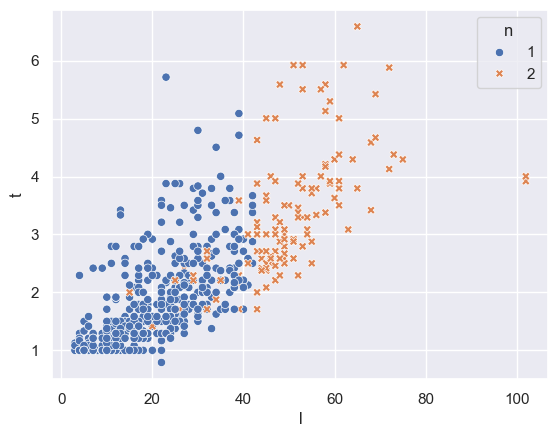

In [3]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("./napisy.csv",index_col=0)
df["n"] = pd.Categorical(df["n"],categories=[1,2])

sns.scatterplot(df, x="l", y="t", style="n", hue="n")
df

## Model

Teraz budujemy model

In [6]:
# Przykładowe dane (zastąp swoimi danymi)
# l - liczba znaków, t - czas trwania, n - liczba linii
l = np.array(df.l)
t = np.array(df.t)
n = np.array(df.n)

# Stworzenie danych wejściowych: łączymy liczbę znaków i liczbę linii
X = np.column_stack((l, n))

# Podział na dane treningowe i testowe
X_train, X_test, t_train, t_test = train_test_split(
    X, t, test_size=0.2, random_state=42
)

# Standaryzacja danych
norm = keras.layers.Normalization()
norm.adapt(X_train)

print(norm.mean)


class ArrayConstant(keras.initializers.Initializer):
    """Inicjalizator ustawiający wagi na zadane wartości tablicowe"""
    def __init__(self, const):
        self.const = keras.ops.array(const)

    def __call__(self, shape, dtype=None):
        assert shape == self.const.shape
        return keras.ops.cast(self.const, dtype=dtype)



# Budowa modelu regresyjnego
model = Sequential(
    [
        keras.layers.Input(shape=(2,)),
        norm,
        Dense(1, kernel_initializer=ArrayConstant([[4.0], [5.0]])),
    ]
)  #

ws = []
bs = []


class ParamsCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        ws.append(self.model.get_weights())
        bs.append(batch)        


# Kompilacja modelu
model.compile(optimizer=keras.optimizers.RMSprop(0.1), loss="mean_squared_error")

# Trenowanie modelu
h = model.fit(
    X_train, t_train, epochs=3, batch_size=8, callbacks=[ParamsCallback()], verbose=0
)


[[27.201313  1.238512]]


Text(0.5, 1.0, '[[0.99675626 0.1606924 ]]')

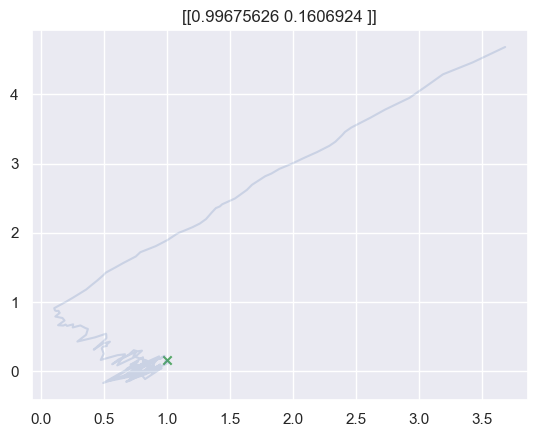

In [7]:
import matplotlib.pyplot as plt

w = np.concatenate([w[-2].T for w in ws], axis=0)
sns.lineplot(x=w[:,0], y=w[:,1], sort=False, alpha=0.2)

plt.scatter(*np.split(model.get_weights()[-2].ravel(), 2), c="C2", marker='x')
plt.title(f"{model.get_weights()[-2].T}")

In [8]:
model.get_weights()

[array([27.201313,  1.238512], dtype=float32),
 array([2.6731616e+02, 1.8162404e-01], dtype=float32),
 array(0, dtype=int32),
 array([[0.99675626],
        [0.1606924 ]], dtype=float32),
 array([1.9831374], dtype=float32)]

[[27.201313  1.238512]]


Text(0.5, 1.0, '[[ 0.68138736 -0.16101544]]')

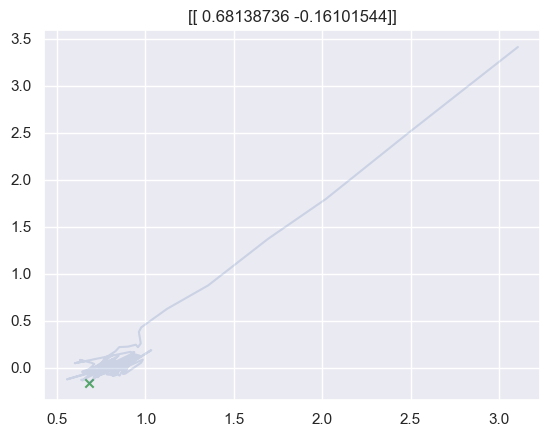

In [9]:
# Przykładowe dane (zastąp swoimi danymi)
# l - liczba znaków, t - czas trwania, n - liczba linii
l = np.array(df.l)
t = np.array(df.t)
n = np.array(df.n)

# Stworzenie danych wejściowych: łączymy liczbę znaków i liczbę linii
X = np.column_stack((l, n))

# Podział na dane treningowe i testowe
X_train, X_test, t_train, t_test = train_test_split(
    X, t, test_size=0.2, random_state=42
)

# Standaryzacja danych
norm = keras.layers.Normalization()
norm.adapt(X_train)

print(norm.mean)


class ArrayConstant(keras.initializers.Initializer):
    """Inicjalizator ustawiający wagi na zadane wartości tablicowe"""
    def __init__(self, const):
        self.const = keras.ops.array(const)

    def __call__(self, shape, dtype=None):
        assert shape == self.const.shape
        return keras.ops.cast(self.const, dtype=dtype)



# Budowa modelu regresyjnego
model = Sequential(
    [
        keras.layers.Input(shape=(2,)),
        norm,
        Dense(1, kernel_initializer=ArrayConstant([[4.0], [5.0]])),
    ]
)  #

ws = []
bs = []


class ParamsCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        ws.append(self.model.get_weights())
        bs.append(batch)        


# Kompilacja modelu
model.compile(optimizer=keras.optimizers.SGD(0.1), loss="mean_squared_error")

# Trenowanie modelu
h = model.fit(
    X_train, t_train, epochs=3, batch_size=8, callbacks=[ParamsCallback()], verbose=0
)

import matplotlib.pyplot as plt

w = np.concatenate([w[-2].T for w in ws], axis=0)
sns.lineplot(x=w[:,0], y=w[:,1], sort=False, alpha=0.2)

plt.scatter(*np.split(model.get_weights()[-2].ravel(), 2), c="C2", marker='x')
plt.title(f"{model.get_weights()[-2].T}")


[[27.201313  1.238512]]


Text(0.5, 1.0, '[[0.5570142 0.195824 ]]')

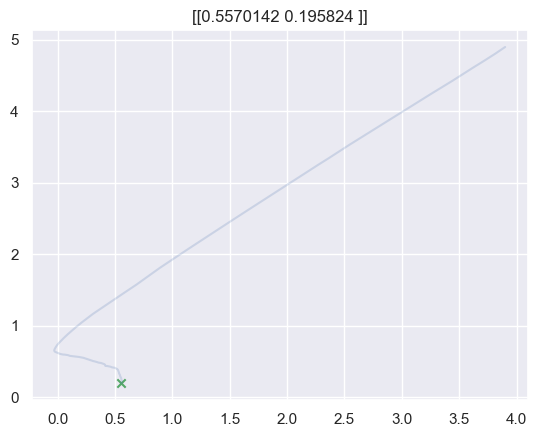

In [10]:
# Przykładowe dane (zastąp swoimi danymi)
# l - liczba znaków, t - czas trwania, n - liczba linii
l = np.array(df.l)
t = np.array(df.t)
n = np.array(df.n)

# Stworzenie danych wejściowych: łączymy liczbę znaków i liczbę linii
X = np.column_stack((l, n))

# Podział na dane treningowe i testowe
X_train, X_test, t_train, t_test = train_test_split(
    X, t, test_size=0.2, random_state=42
)

# Standaryzacja danych
norm = keras.layers.Normalization()
norm.adapt(X_train)

print(norm.mean)


class ArrayConstant(keras.initializers.Initializer):
    """Inicjalizator ustawiający wagi na zadane wartości tablicowe"""
    def __init__(self, const):
        self.const = keras.ops.array(const)

    def __call__(self, shape, dtype=None):
        assert shape == self.const.shape
        return keras.ops.cast(self.const, dtype=dtype)



# Budowa modelu regresyjnego
model = Sequential(
    [
        keras.layers.Input(shape=(2,)),
        norm,
        Dense(1, kernel_initializer=ArrayConstant([[4.0], [5.0]])),
    ]
)  #

ws = []
bs = []


class ParamsCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        ws.append(self.model.get_weights())
        bs.append(batch)        


# Kompilacja modelu
model.compile(optimizer=keras.optimizers.Adam(0.1), loss="mean_squared_error")

# Trenowanie modelu
h = model.fit(
    X_train, t_train, epochs=3, batch_size=8, callbacks=[ParamsCallback()], verbose=0
)

import matplotlib.pyplot as plt

w = np.concatenate([w[-2].T for w in ws], axis=0)
sns.lineplot(x=w[:,0], y=w[:,1], sort=False, alpha=0.2)

plt.scatter(*np.split(model.get_weights()[-2].ravel(), 2), c="C2", marker='x')
plt.title(f"{model.get_weights()[-2].T}")


# Zadanie - Analiza wpływu parametrów i optymalizatorów na proces uczenia modelu regresyjnego

Celem tego zadania jest pogłębienie wiedzy na temat optymalizacji sieci neuronowych oraz roli, jaką odgrywają parametry takie jak *learning_rate*, *batch_size* oraz *epochs*. Dodatkowo, zbadamy różne optymalizatory, aby lepiej zrozumieć, jak wpływają one na proces uczenia modelu. Waszym zadaniem będzie także zaimplementowanie brakującej funkcjonalności w klasach.

## Kroki do wykonania:

### 1. **Zaimplementowanie klas, gdzie użyto `pass`**

W kodzie istnieją dwie klasy, które nie mają jeszcze zaimplementowanej logiki:

- **`ArrayConstant`**: Ta klasa jest inicjalizatorem wartości wag w sieci neuronowej. Należy zdefiniować, jak inicjalizować wagi za pomocą macierzy przekazywanej jako argument.
  
  - **Podpowiedź**: Przejrzyj dokumentację Keras dotyczącą tworzenia własnych inicjalizatorów (https://keras.io/api/layers/initializers/). Należy zaimplementować metodę `__call__`, która zwraca odpowiednio zainicjalizowane wagi.

- **`ParamsCallback`**: Jest to callback, który pozwoli na śledzenie parametrów modelu podczas trenowania. Należy rozszerzyć go o funkcjonalność, która będzie zbierać i przechowywać wartości wag oraz biasów po każdej epoce.

  - **Podpowiedź**: Wykorzystaj metody `on_train_batch_end()` i `model.get_weights()`, aby zapisywać parametry.

### 2. **Eksperymenty z optymalizatorami i ich parametrami**

W tej części zadania będziecie eksplorować różne konfiguracje optymalizatorów i parametrów treningowych, aby lepiej zrozumieć, jak wpływają one na jakość modelu oraz proces jego trenowania.

#### 2.1. **Różne punkty startowe**

- **Cel**: Zbadać, jak różne punkty startowe (inicjalizacje wag) wpływają na proces optymalizacji. Wyznaczcie minimum cztery różne zestawy początkowych wag w różnych ćwiartkach układu współrzędnych.
  
  - **Podpowiedź**: Możecie zdefiniować różne macierze inicjalizacyjne dla klasy `ArrayConstant` i przekazywać je do modelu. Upewnijcie się, że wagi są różne dla każdego eksperymentu, aby dokładnie zbadać wpływ inicjalizacji.

#### 2.2. **Testowanie różnych optymalizatorów**

- **Cel**: Zbadać wpływ różnych optymalizatorów na proces uczenia. Wybierzcie trzy optymalizatory: `SGD`, `Adam` oraz `RMSProp`.

  - **Podpowiedź**: Każdy optymalizator ma swoje specyficzne właściwości. Na przykład:
    - `SGD` (stochastic gradient descent) jest jednym z najprostszych optymalizatorów i może być wrażliwy na wartość *learning_rate*.
    - `Adam` łączy zalety dwóch innych metod: RMSProp i momentu.
    - `RMSProp` dynamicznie dostosowuje kroki optymalizacyjne, co może być korzystne dla trudniejszych problemów.
  
  - **Zadanie**: Dla każdego z optymalizatorów wykonajcie trening modelu i porównajcie ich działanie na podstawie strat (loss) oraz szybkości zbieżności.

#### 2.3. **Wpływ parametrów uczenia**

- **Cel**: Zbadać, jak parametry takie jak *learning_rate*, *batch_size* oraz *epochs* wpływają na proces trenowania i jakość modelu.
  
  - **Podpowiedź**: 
    - Zmieniajcie wartość *learning_rate* w przedziale np. [0.01, 0.05, 0.1, 0.2] i obserwujcie, jak zmienia się szybkość uczenia oraz zbieżność.
    - Przetestujcie różne rozmiary batchów (np. [8, 16, 32]), aby zobaczyć, jak wpływa to na dokładność modelu i stabilność procesu uczenia.
    - Wykonajcie eksperymenty z różną liczbą epok (np. [3, 10, 50]) .

### 3. **Prezentacja wyników**

Zadaniem jest nie tylko przeprowadzenie eksperymentów, ale również ich szczegółowe przedstawienie. Wyniki muszą być zilustrowane za pomocą odpowiednich wizualizacji.

#### 3.1. **Wizualizacje strat w czasie**
  
- Należy przedstawić wykresy porównujące zmianę funkcji kosztu (loss) w zależności od epok dla różnych optymalizatorów i konfiguracji parametrów.

#### 3.2. **Porównanie wag**

- Zilustrujcie, jak zmieniają się wagi modelu po każdej epoce dla różnych optymalizatorów. Wykorzystajcie callback do zapisu wag i przedstawcie ich wartości graficznie.

#### 3.3. **Wpływ parametrów**

- Zróbcie wykresy pokazujące, jak *learning_rate*, *batch_size* oraz *epochs* wpływają na szybkość zbieżności oraz jakość ostatecznego modelu.

---

## Podsumowanie

Zadanie to pozwoli Wam lepiej zrozumieć mechanizmy uczenia modeli w sieciach neuronowych oraz wpływ różnych elementów na proces trenowania. Skupcie się na dokładnym dokumentowaniu obserwacji, ponieważ kluczowe jest wyciąganie wniosków na podstawie uzyskanych wyników.
